# **🚨Comment Toxicity**

# *Import Necessary Libraries*

In [1]:
# 📦 Data handling libraries
import pandas as pd              
import numpy as np               

# 📊 Visualization libraries
import matplotlib.pyplot as plt  
import seaborn as sns            

# 🔤 Text processing
import re                        

# ⚙️ Deep Learning - Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# 🔀 Train-Test Split
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_auc_score


# 🤖 Deep Learning - TensorFlow / Keras
import tensorflow as tf      

from tensorflow.keras.models import Sequential       
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D 
from keras.layers import Input , Bidirectional, LSTM
from tensorflow.keras.layers import Conv1D           
from tensorflow.keras.layers import GlobalMaxPooling1D  
from tensorflow.keras.layers import Dense            
from tensorflow.keras.layers import Dropout      
   

# 🔢 Tokenization & Padding (for Neural Networks)
from tensorflow.keras.preprocessing.text import Tokenizer   
from tensorflow.keras.preprocessing.sequence import pad_sequences  

# 🧠 Natural Language Processing
import nltk                             
from nltk.corpus import stopwords        # Stopwords removal

# ⛔ Ignore warnings
import warnings
warnings.filterwarnings("ignore")        

# 📂 Load the train and  dataset

In [7]:
train_df = pd.read_csv('train.csv')
test_df =pd.read_csv('test.csv')
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [8]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [9]:
train_df.shape

(159571, 8)

In [10]:
test_df.shape

(153164, 2)

In [11]:
train_df.dtypes

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

In [12]:
# dataset stats
train_df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [14]:
train_df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [15]:
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

counts_list = []

for col in label_cols:
    counts_list.append(train_df[col].sum())

label_counts = pd.Series(counts_list, index=label_cols)

print(label_counts)


toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [16]:
rowsums = train_df.iloc[:, 2:].sum(axis=1) # take label row-wise and sum of label columns
rowsums

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [17]:
no_label_count = 0

for i, count in rowsums.items():
    if count==0:
        no_label_count += 1
        
print('Total number of comments:', len(train_df))
print('Total number of clean comments :', no_label_count)
print('Total labels:', label_counts.sum())

Total number of comments: 159571
Total number of clean comments : 143346
Total labels: 35098


## **Label Counts**

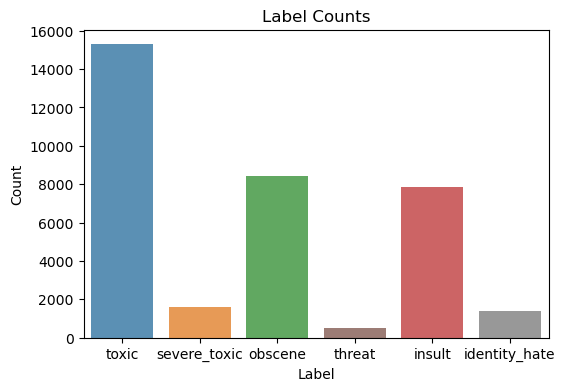

In [18]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=label_counts.index, y=label_counts.values,
alpha=0.8, palette=['tab:blue', 'tab:orange','tab:green', 'tab:brown', 'tab:red', 'tab:grey'])

plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')

plt.show()

# 🧹   **Data Prepocessing**

In [19]:
train_df = train_df.drop(columns=['id'], axis=1)
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [20]:
test_df = test_df.drop(columns=['id'], axis=1)
test_df.head()

,comment_text
0,Yo bitch Ja Rule is more succesful then you'll...
1,== From RfC == \n\n The title is fine as it is...
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,":If you have a look back at the source, the in..."
4,I don't anonymously edit articles at all.


## **Cleaning**

In [21]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text 

In [22]:
# 1. Clean Training Data (Use train_df here)
train_df['comment_text'] = train_df['comment_text'].apply(lambda x: clean(x))
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,daww he matches this background colour im seem...,0,0,0,0,0,0
2,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [23]:
# 2. Clean Test Data (Use test_df here)
test_df['comment_text'] = test_df['comment_text'].apply(lambda x: clean(x))
test_df.head()

,comment_text
0,yo bitch ja rule is more succesful then youll ...
1,from rfc the title is fine as it is imo
2,sources zawe ashton on lapland
3,if you have a look back at the source the info...
4,i dont anonymously edit articles at all


#  **Stopword Removal**

In [24]:
def remove_stopwords(text):

    stop_words = set(stopwords.words('english')) # Defined inside now!
    words = str(text).split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [25]:
train_df['comment_text'] = train_df['comment_text'].apply(clean)

In [26]:
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,daww he matches this background colour im seem...,0,0,0,0,0,0
2,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [27]:
test_df['comment_text'] = test_df['comment_text'].apply(clean)

In [28]:
test_df.head()

,comment_text
0,yo bitch ja rule is more succesful then youll ...
1,from rfc the title is fine as it is imo
2,sources zawe ashton on lapland
3,if you have a look back at the source the info...
4,i dont anonymously edit articles at all


In [29]:
initial_rows = train_df.shape[0] 
train_df.drop_duplicates(subset=['comment_text'], inplace=True) 
train_df.reset_index(drop=True, inplace=True) 

print(f"Duplicates Removed: {initial_rows - train_df.shape[0]}")

print(f"Final Train Shape: {train_df.shape}") 

Duplicates Removed: 1351
Final Train Shape: (158220, 7)


In [30]:
train_df.isnull().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [31]:
initial_shape_test = test_df.shape
test_df.drop_duplicates(subset=['comment_text'], inplace=True) 
test_df.reset_index(drop=True, inplace=True)

print(f"Duplicates Removed from Test: {initial_shape_test[0] - test_df.shape[0]}")


print(f"Final Test Shape: {test_df.shape}") 

Duplicates Removed from Test: 2362
Final Test Shape: (150802, 1)


# **Tokenization**

### Independent Variable (X) – Input

In [32]:
# 1. Tokenizer setup

MAX_WORDS = 20000
MAX_LEN = 150
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['comment_text'])


In [33]:
# 2.Apply Padding for Train

train_sequences = tokenizer.texts_to_sequences(train_df['comment_text'])
X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post')

In [34]:
# 3. Apply Padding for Test

test_sequences = tokenizer.texts_to_sequences(test_df['comment_text'])
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post')

In [35]:
print("✅ Tokenization and Padding Complete!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")

✅ Tokenization and Padding Complete!
X_train Shape: (158220, 150)
X_test Shape: (150802, 150)


## **Data is normalized scaling not required**

In [36]:
X_train[0]

array([  641,    76,     2,   122,   126,   172,    28,   660,  4504,
       11305,  1038,    83,   325,    53,  1999, 10753,    51,  6429,
          16,    62,  2606,   143,     8,  2755,    34,   113,  1131,
       15097,  2786,     5,    48,    55,   235,     2,   410,    31,
           2,    43,    29,   142,    70,  3365,    90,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

#  **Prepare Target labels**

### Dependent Variable (y) – Output / Target

In [37]:
target_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
y_train = train_df[target_cols].values
print("Target labels y_train shape:", y_train.shape)

Target labels y_train shape: (158220, 6)


# **Train–Validation Data Split**

In [38]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print("Train:", X_tr.shape, y_tr.shape)
print("Val  :", X_val.shape, y_val.shape)

Train: (142398, 150) (142398, 6)
Val  : (15822, 150) (15822, 6)


# **1) . CNN Model**

### **Model Train**

In [39]:
# 1. Build CNN Model and input

cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    SpatialDropout1D(0.3),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(6, activation="sigmoid")])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Accuracy'])

In [40]:
# 2. Train CNN Model
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_Accuracy", mode="max", patience=2, restore_best_weights=True)]

print(" Training CNN Model...")

# This will now work even if you didn't run the LSTM cell first

cnn_history = cnn_model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=5, batch_size=128,callbacks=callbacks)
print(" CNN Training Finished!")

 Training CNN Model...
Epoch 1/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 157s 138ms/step - Accuracy: 0.8822 - loss: 0.0740 - val_Accuracy: 0.9940 - val_loss: 0.0512
Epoch 2/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 154s 139ms/step - Accuracy: 0.9720 - loss: 0.0473 - val_Accuracy: 0.9940 - val_loss: 0.0504
Epoch 3/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 139s 125ms/step - Accuracy: 0.9538 - loss: 0.0410 - val_Accuracy: 0.9933 - val_loss: 0.0501
 CNN Training Finished!


# **Model Evaluation**

In [41]:
loss, Accuracy = cnn_model.evaluate(X_val, y_val)
print(f"CNN Validation Loss: {loss:.4f}")
print(f"CNN Validation Accuracy : {Accuracy:.4f}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - Accuracy: 0.9940 - loss: 0.0512
CNN Validation Loss: 0.0512
CNN Validation Accuracy : 0.9940


In [42]:

val_probs = cnn_model.predict(X_val)

print("\n📊 CNN Model Evaluation (Accuracy Scores):")
print("-" * 35)
total_auc = 0
for i, col in enumerate(target_cols):
    auc = roc_auc_score(y_val[:, i], val_probs[:, i])
    total_auc += auc
    print(f"{col:15}: {auc:.4f}")

print("-" * 35)
print(f"Mean Accuracy Score  : {total_auc/len(target_cols):.4f}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

📊 CNN Model Evaluation (Accuracy Scores):
-----------------------------------
toxic          : 0.9740
severe_toxic   : 0.9887
obscene        : 0.9850
threat         : 0.9422
insult         : 0.9801
identity_hate  : 0.9574
-----------------------------------
Mean Accuracy Score  : 0.9712


# **2) . LSTMs Model**

### **Model Train**

In [44]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(6, activation="sigmoid")])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Accuracy'])

print(" Training LSTM Model...")
lstm_history = lstm_model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=5, batch_size=128, callbacks=callbacks)
print(" LSTM Training Finished!")

 Training LSTM Model...
Epoch 1/5


KeyboardInterrupt: 

# **Model Evaluation**

In [ ]:
loss, Accuracy = lstm_model.evaluate(X_val, y_val)
print(f"LSTM Validation Loss: {loss:.4f}")
print(f"LSTM Validation Accuracy : {Accuracy:.4f}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - Accuracy: 0.9940 - loss: 0.0501
LSTM Validation Loss: 0.0501
LSTM Validation Accuracy : 0.9940


In [ ]:
lstm_probs = lstm_model.predict(X_val)

metrics = []
for i, col in enumerate(target_cols):
    lstm_auc = roc_auc_score(y_val[:, i], lstm_probs[:, i])
    metrics.append({
        'Category': col,
        'LSTM Accuracy': round(lstm_auc, 4)
    })

evaluation_df = pd.DataFrame(metrics)
print("\n📊 LSTM Model Evaluation (Accuracy):")
print(evaluation_df.to_string(index=False))

print(f"\nMean LSTM Accuracy: {evaluation_df['LSTM Accuracy'].mean():.4f}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step

📊 LSTM Model Evaluation (Accuracy):
     Category  LSTM Accuracy
        toxic         0.9767
 severe_toxic         0.9883
      obscene         0.9858
       threat         0.9514
       insult         0.9808
identity_hate         0.9607

Mean LSTM Accuracy: 0.9739


#  **Prediction**
### Predict toxicity for new comments.

In [ ]:
def compare_models(text):
    # 1. Print input text first (Indha line thaan add panniruken)
    print(f"\n💬 Input: '{text}'")
    
    # 2. Preprocess and Predict
    cleaned = clean(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    
    lstm_probs = lstm_model.predict(pad)[0]
    cnn_probs = cnn_model.predict(pad)[0]
    
    # 3. Return Table
    comparison_df = pd.DataFrame({
        'Category': target_cols,
        'LSTM Score': [round(float(p), 4) for p in lstm_probs],
        'CNN Score': [round(float(p), 4) for p in cnn_probs]
    })
    return comparison_df

# --- RUN THE TEST ---
test_comment = "You are an absolute idiot and I hate you."
compare_models(test_comment)


💬 Input: 'You are an absolute idiot and I hate you.'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


,Category,LSTM Score,CNN Score
0,toxic,0.9743,0.9742
1,severe_toxic,0.1952,0.2201
2,obscene,0.8652,0.8146
3,threat,0.0490,0.0467
4,insult,0.8023,0.7024
5,identity_hate,0.1402,0.1758


# **Model comparison**

In [ ]:
from sklearn.metrics import roc_auc_score

# Predictions
cnn_auc = roc_auc_score(y_val, cnn_model.predict(X_val))
lstm_auc = roc_auc_score(y_val, lstm_model.predict(X_val))

print(f"📊 CNN Mean Accuracy  : {cnn_auc:.4f}")
print(f"📊 LSTM Mean Accuracy : {lstm_auc:.4f}")
print(f"🏆 Best Model: {'LSTM' if lstm_auc > cnn_auc else 'CNN'}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step
📊 CNN Mean Accuracy  : 0.9712
📊 LSTM Mean Accuracy : 0.9739
🏆 Best Model: LSTM


In [ ]:
print("🏆 MODEL JUSTIFICATION")
print("-" * 30)
print("1. CNN  : Best for fast pattern matching (keywords).")
print("2. LSTM : Best for context & sequence understanding.")

# Score comparison logic
print(f"\n✅ Best Model : {'LSTM' if lstm_auc > cnn_auc else 'CNN'} is chosen for higher accuracy.")   

🏆 MODEL JUSTIFICATION
------------------------------
1. CNN  : Best for fast pattern matching (keywords).
2. LSTM : Best for context & sequence understanding.

✅ Best Model : LSTM is chosen for higher accuracy.


# **Models Save** 

In [ ]:
import os, pickle

os.makedirs("toxicity_model", exist_ok=True)

best_model = lstm_model if lstm_auc > cnn_auc else cnn_model
best_model.save("toxicity_model/best_toxicity_model.h5")

pickle.dump(tokenizer, open("toxicity_model/tokenizer.pkl", "wb"))

print("✅ Saved inside toxicity_model folder")


✅ Saved inside toxicity_model folder
